In [1]:
%pip install torch ta mplfinance scikit-learn matplotlib pandas numpy

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 9.3 MB/s eta 0:00:00
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=1092119342159e830e69e8a68b9c9acf9958ba6bb2310c14ebd647f910b287c6
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


Mounted at /content/drive
Using device: cuda
Loading data from: /content/drive/MyDrive/CryptoProject/processed_data_transformer/BTCUSDT
Epoch 1/30 | Train Loss: 0.017829 | Val Loss: 0.014427
Epoch 2/30 | Train Loss: 0.015803 | Val Loss: 0.014246
Epoch 3/30 | Train Loss: 0.015545 | Val Loss: 0.013986
Epoch 4/30 | Train Loss: 0.015445 | Val Loss: 0.014367
Epoch 5/30 | Train Loss: 0.015331 | Val Loss: 0.014249
Epoch 6/30 | Train Loss: 0.015243 | Val Loss: 0.013945
Epoch 7/30 | Train Loss: 0.015144 | Val Loss: 0.014062
Epoch 8/30 | Train Loss: 0.015121 | Val Loss: 0.014205
Epoch 9/30 | Train Loss: 0.015085 | Val Loss: 0.014262
Epoch 10/30 | Train Loss: 0.015053 | Val Loss: 0.013991
Epoch 11/30 | Train Loss: 0.015042 | Val Loss: 0.013931
Epoch 12/30 | Train Loss: 0.014985 | Val Loss: 0.014126
Epoch 13/30 | Train Loss: 0.014937 | Val Loss: 0.013920
Epoch 14/30 | Train Loss: 0.014911 | Val Loss: 0.014103
Epoch 15/30 | Train Loss: 0.014912 | Val Loss: 0.013965
Epoch 16/30 | Train Loss: 0.01486

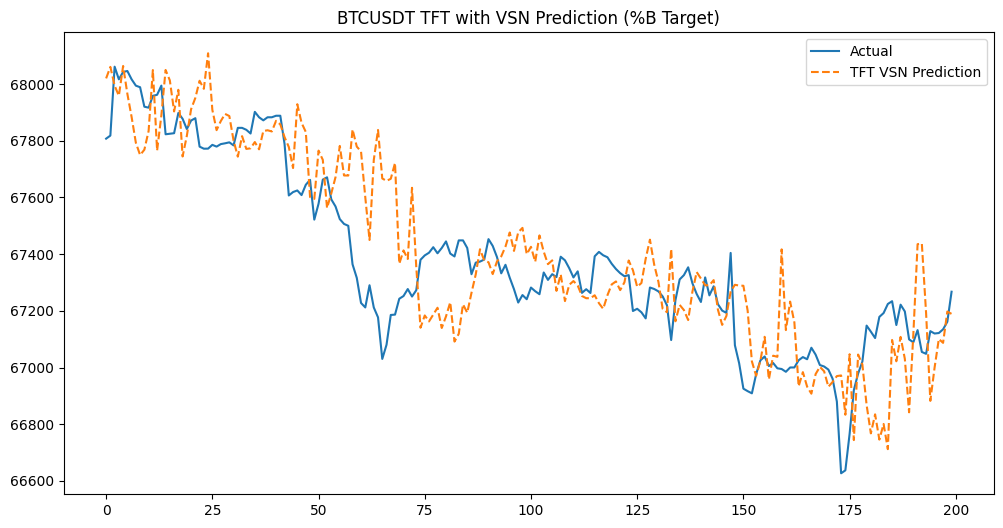

In [2]:
%pip install torch ta mplfinance scikit-learn matplotlib pandas

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import mplfinance as mpf
import pandas as pd
import math
import ta

# --- הגדרת המטבע ---
SYMBOL = 'BTCUSDT'

# --- 1. חיבור לגוגל דרייב ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/CryptoProject'
except ImportError:
    BASE_DIR = os.getcwd()

# --- הגדרות נתיבים מעודכנות לפי המטבע ---
DATA_DIR = os.path.join(BASE_DIR, 'processed_data_transformer', SYMBOL)
MODEL_DIR = os.path.join(BASE_DIR, 'models')
if not os.path.exists(MODEL_DIR): os.makedirs(MODEL_DIR)

BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 0.001
D_MODEL = 64
N_HEADS = 4
NUM_LAYERS = 2
DROPOUT = 0.2

# ---------------------------------------------------------
# 1. TFT Components: GLU, GRN, VSN
# ---------------------------------------------------------
class GLU(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc = nn.Linear(input_size, input_size * 2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc(x)
        content, gate = torch.chunk(x, 2, dim=-1)
        return content * self.sigmoid(gate)

class GRN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=None, dropout=0.1):
        super().__init__()
        output_size = output_size or input_size
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.glu = GLU(output_size)
        self.layer_norm = nn.LayerNorm(output_size)
        self.dropout = nn.Dropout(dropout)
        self.skip = nn.Linear(input_size, output_size) if input_size != output_size else nn.Identity()

    def forward(self, x):
        residual = self.skip(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.dropout(x)
        x = self.glu(x)
        return self.layer_norm(residual + x)

class VariableSelectionNetwork(nn.Module):
    def __init__(self, input_dim, num_vars, d_model, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.num_vars = num_vars
        self.grns = nn.ModuleList([GRN(input_dim // num_vars, d_model, d_model, dropout) for _ in range(num_vars)])
        self.selector_grn = GRN(input_dim, d_model, num_vars, dropout)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        # x shape: (batch, seq, input_dim)
        weights = self.softmax(self.selector_grn(x)) # (batch, seq, num_vars)

        var_outputs = []
        chunk_size = x.shape[-1] // self.num_vars
        for i in range(self.num_vars):
            var_x = x[..., i*chunk_size : (i+1)*chunk_size]
            var_outputs.append(self.grns[i](var_x)) # (batch, seq, d_model)

        var_outputs = torch.stack(var_outputs, dim=-1) # (batch, seq, d_model, num_vars)
        selected_output = torch.sum(var_outputs * weights.unsqueeze(-2), dim=-1)
        return selected_output

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TFTModel(nn.Module):
    def __init__(self, input_dim, num_vars, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.vsn = VariableSelectionNetwork(input_dim, num_vars, d_model, dropout)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead, d_model*4, dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.vsn(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        return self.fc(x[:, -1, :])

# ---------------------------------------------------------
# 2. Training Logic
# ---------------------------------------------------------
def train():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    print(f"Loading data from: {DATA_DIR}")

    X_train = torch.tensor(np.load(os.path.join(DATA_DIR, 'X_train.npy')), dtype=torch.float32).to(device)
    y_train = torch.tensor(np.load(os.path.join(DATA_DIR, 'y_train.npy')), dtype=torch.float32).to(device)
    X_val = torch.tensor(np.load(os.path.join(DATA_DIR, 'X_val.npy')), dtype=torch.float32).to(device)
    y_val = torch.tensor(np.load(os.path.join(DATA_DIR, 'y_val.npy')), dtype=torch.float32).to(device)
    X_test = torch.tensor(np.load(os.path.join(DATA_DIR, 'X_test.npy')), dtype=torch.float32).to(device)
    y_test = np.load(os.path.join(DATA_DIR, 'y_test.npy'))

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)

    model = TFTModel(input_dim=X_train.shape[2], num_vars=X_train.shape[2], d_model=D_MODEL).to(device)

    # HuberLoss is better balanced for values like %B (0-1 range)
    criterion = nn.HuberLoss(delta=1.0)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_val_loss = float('inf')

    # עדכון שם השמירה של המודל לפי המטבע
    model_save_path = os.path.join(MODEL_DIR, f'best_tft_vsn_{SYMBOL}.pth')

    for epoch in range(EPOCHS):
        model.train()
        total_train_loss = 0
        for bx, by in train_loader:
            optimizer.zero_grad()
            pred = model(bx).squeeze()
            loss = criterion(pred, by)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for bx, by in val_loader:
                pred = model(bx).squeeze()
                total_val_loss += criterion(pred, by).item()

        avg_val = total_val_loss / len(val_loader)
        scheduler.step(avg_val)
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {total_train_loss/len(train_loader):.6f} | Val Loss: {avg_val:.6f}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), model_save_path)

    # Evaluation
    model.load_state_dict(torch.load(model_save_path))
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_test), BATCH_SIZE):
            preds.extend(model(X_test[i:i+BATCH_SIZE]).squeeze().cpu().numpy())

    # Visualization Reconstruct - קריאת הנתונים הגולמיים המעודכנת
    csv_path = os.path.join(BASE_DIR, 'data', f'{SYMBOL}_5m_data.csv')
    df_raw = pd.read_csv(csv_path)
    bb = ta.volatility.BollingerBands(df_raw['close'], window=20, window_dev=2)
    upper = bb.bollinger_hband().values
    lower = bb.bollinger_lband().values

    # Find the correct offset for test set
    test_offset = len(df_raw) - len(preds)
    actual_prices = df_raw['close'].values[test_offset:]
    pred_prices = lower[test_offset:] + (np.array(preds) * (upper[test_offset:] - lower[test_offset:]))

    plt.figure(figsize=(12, 6))
    plt.plot(actual_prices[:200], label='Actual')
    plt.plot(pred_prices[:200], label='TFT VSN Prediction', linestyle='--')
    plt.title(f"{SYMBOL} TFT with VSN Prediction (%B Target)")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    train()